### Summary of Integrated Hyperspectral Workflow

This end-to-end analytical pipeline demonstrates the power of high-resolution SWIR and optical hyperspectral sensing (via Tanager data) for urban microclimate and material modeling across Jacksonville:

* **Atmospheric & Surface Disambiguation:** By comparing water vapor column maps and spectral baseline regressions, atmospheric moisture anomalies were successfully decoupled from true point-source gas emissions and reflective synthetic materials (e.g., warehouse roofs).
* **Thermal & Microclimate Dynamics:** Combining SWIR thermal radiance proxies ($2480\text{ nm} / 2220\text{ nm}$) with Phase-Flux indices provided a clear picture of localized sensible heat storage, surface liquid evaporation, and photon path-length scattering across complex coastal-urban geometries.
* **Material & Structural Profiling:** Specific absorption feature analysis pinpointed synthetic polymer footprints ($1730\text{ nm}$ overtone), photocatalytic $\text{TiO}_2$ smart surfaces ($390\text{ nm}$ bandgap), and structural energy trapping via the Anisotropic Cavity Trap Index (ACTI).
* **Biological Vitality & Ecotone Mapping:** Oxygen-A infill ($760.4\text{ nm}$) enabled direct mapping of real-time Solar-Induced Fluorescence (SIF), culminating in a unified RGB physics-space composite that cleanly separates natural carbon sinks from thermal urban batteries.

This integrated multi-dimensional framework equips municipal leaders and researchers with actionable geospatial data to mitigate urban heat island effects, optimize energy infrastructure, and build climate-resilient urban environments.

### Introduction: 

Jacksonville features dense coastal vegetation, inland waterways, estuarine marshes, asphalt highways, concrete infrastructure, and industrial port areas all captured within a single swath. This environmental complexity makes Jacksonville a perfect benchmark dataset for testing atmospheric correction, evaluating spectral quality, and demonstrating material classification techniques on Tanager data.

Here, the dataset (hyperspectral cube) is loaded, its wavelength rage is determined and no data  pixel values (if any) are checked and fill values ae determined

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

#1. Load the data
file_path = "dataset/20250516_164837_16_4001_basic_sr_hdf5.h5"

with h5py.File(file_path, 'r') as f:
    sr_dataset = f['HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance']
    cloud_mask = f['HDFEOS/SWATHS/HYP/Data Fields/beta_cloud_mask'][:]
    water_vapor = f['HDFEOS/SWATHS/HYP/Data Fields/column_water_vapour'][:]
    nodata = f['HDFEOS/SWATHS/HYP/Data Fields/nodata_pixels'][:]
    path_length = f['HDFEOS/SWATHS/HYP/Data Fields/sensor_to_ground_path_length'][:]
    # Extract the attributes cleanly
    wavelengths = sr_dataset.attrs['wavelengths'][:]
    good_bands = sr_dataset.attrs['good_wavelengths'][:]
    
    # Handle string decoding safely for units
    wl_units = sr_dataset.attrs['wavelengths_units']
    if isinstance(wl_units, bytes):
        wl_units = wl_units.decode('utf-8')
    elif isinstance(wl_units, np.ndarray):
        wl_units = wl_units[0].decode('utf-8') if isinstance(wl_units[0], bytes) else wl_units[0]

    # FIX: Read fill value as a scalar directly
    fill_value = sr_dataset.attrs['_FillValue']
    if isinstance(fill_value, np.ndarray):
        fill_value = fill_value[0] # Only index if it actually loaded as an array
    
    # Load the actual data cube (bands, rows, cols)
    sr_cube = sr_dataset[:].astype(np.float32)



print(f"Spectral Range: {wavelengths.min():.2f} to {wavelengths.max():.2f} {wl_units}")
print(f"Number of 'Good' Bands: {int(good_bands.sum())} out of {len(good_bands)}")
print(f"Detected Fill Value: {fill_value}")

# Clean up fill/bad values using our fixed scalar
sr_cube[sr_cube == fill_value] = np.nan
sr_cube[sr_cube < 0] = np.nan

Spectral Range: 376.44 to 2499.00 nm
Number of 'Good' Bands: 368 out of 426
Detected Fill Value: -9999.0


To evaluate data quality across the scene, we construct a 2×2 multi-panel diagnostic dashboard that visualizes the spatial distribution of surface reflectance alongside key environmental and quality masks. 

Inspecting these spatial patterns together ensures we can systematically flag low-quality pixels and atmospheric distortions before running quantitative algorithms:

* **Top-Left (Surface Reflectance - Band 80):** Displays a single Near-Infrared (NIR) band rendered with the `viridis` colormap to highlight structural surface features, vegetation density, and land-water boundaries with high contrast.
* **Top-Right (Column Water Vapor):** Visualizes estimated atmospheric water vapor concentrations to evaluate regional atmospheric interference across the flight path.
* **Bottom-Left (Beta Cloud Mask):** Isolates opaque cloud cover and shadow artifacts to prevent contamination in downstream analytical steps.
* **Bottom-Right (NoData Pixel Mask):** Pinpoints explicit missing or corrupted sensor telemetry to ensure unmapped pixels are properly ignored.

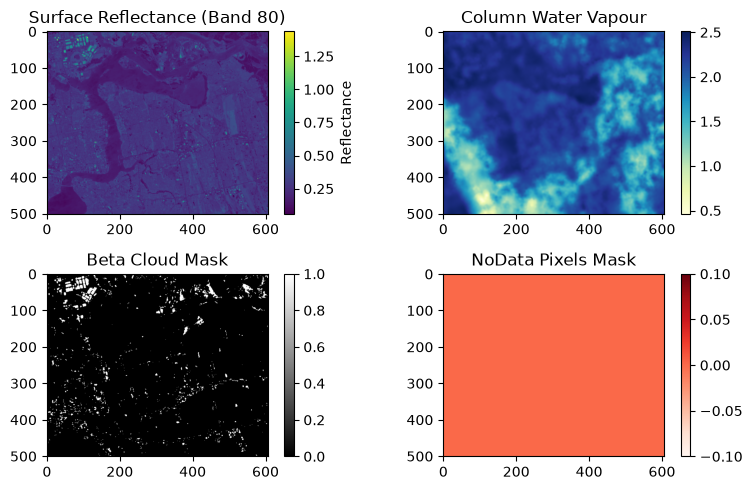

In [15]:
# 2. Select bands for a quick visualization
# If we don't know the exact wavelengths, let's pick 3 spread out early bands 
# to mimic an RGB composite, or just look at a single near-infrared band (e.g., band 80)
band_idx = 80
single_band = sr_cube[band_idx, :, :]

# 3. Plotting the EDA Dashboard
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

# Top Left: Single Spectral Band
im1 = axes[0, 0].imshow(single_band, cmap='viridis')
axes[0, 0].set_title(f"Surface Reflectance (Band {band_idx})")
fig.colorbar(im1, ax=axes[0, 0], label='Reflectance')

# Top Right: Water Vapor
im2 = axes[0, 1].imshow(water_vapor, cmap='YlGnBu')
axes[0, 1].set_title("Column Water Vapour")
fig.colorbar(im2, ax=axes[0, 1])

# Bottom Left: Cloud Mask
im3 = axes[1, 0].imshow(cloud_mask, cmap='gray')
axes[1, 0].set_title("Beta Cloud Mask")
fig.colorbar(im3, ax=axes[1, 0])

# Bottom Right: NoData Pixels
im4 = axes[1, 1].imshow(nodata, cmap='Reds')
axes[1, 1].set_title("NoData Pixels Mask")
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

### True Color Composite & Spectral Profile Extraction

This step constructs a realistic True Color (RGB) image from the hyperspectral cube and extracts the spectral signature of a representative central pixel. By automatically detecting the wavelength units—micrometers ($\mu m$) or nanometers ($nm$)—the code identifies the spectral bands nearest to standard Red (~650 nm), Green (~550 nm), and Blue (~470 nm) central wavelengths. A 2nd–98th percentile linear contrast stretch normalizes reflectance values to an displayable $[0, 1]$ range for visual inspection, while the adjacent plot isolates a single pixel's reflectance curve, highlighting valid measurements in teal to visually distinguish high-quality spectral bands from noisy atmospheric absorption regions.

Selected RGB Bands indices: Red=55, Green=35, Blue=19


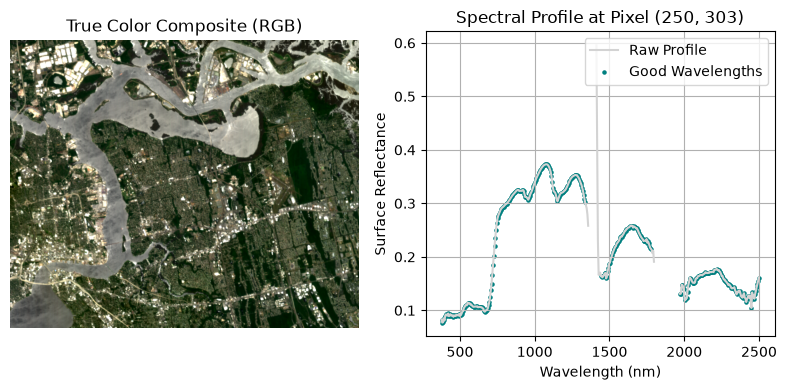

In [68]:
# --- Find Red, Green, Blue bands ---
is_micrometers = wavelengths.max() < 100
r_target = 0.65 if is_micrometers else 650
g_target = 0.55 if is_micrometers else 550
b_target = 0.47 if is_micrometers else 470

b_red = np.argmin(abs(wavelengths - r_target))
b_green = np.argmin(abs(wavelengths - g_target))
b_blue = np.argmin(abs(wavelengths - b_target))

print(f"Selected RGB Bands indices: Red={b_red}, Green={b_green}, Blue={b_blue}")

# Extract RGB channels and stack them
rgb = np.zeros((sr_cube.shape[1], sr_cube.shape[2], 3))
rgb[..., 0] = sr_cube[b_red, :, :]
rgb[..., 1] = sr_cube[b_green, :, :]
rgb[..., 2] = sr_cube[b_blue, :, :]

# Simple contrast stretch for visualization (percentile clip)
p2, p98 = np.nanpercentile(rgb, (2, 98))
rgb_clipped = np.clip((rgb - p2) / (p98 - p2), 0, 1)
rgb_clipped[np.isnan(rgb_clipped)] = 0 

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Left plot: True Color Image
ax1.imshow(rgb_clipped)
ax1.set_title("True Color Composite (RGB)")
ax1.axis('off')

# Right plot: Spectral Profile of a single pixel in the center
mid_row, mid_col = sr_cube.shape[1] // 2, sr_cube.shape[2] // 2
pixel_profile = sr_cube[:, mid_row, mid_col]

ax2.plot(wavelengths, pixel_profile, label='Raw Profile', color='lightgray')
ax2.scatter(wavelengths[good_bands == 1], pixel_profile[good_bands == 1], 
           s=5, color='teal', label='Good Wavelengths')

ax2.set_title(f"Spectral Profile at Pixel ({mid_row}, {mid_col})")
ax2.set_xlabel(f"Wavelength ({wl_units})")
ax2.set_ylabel("Surface Reflectance")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Methane Spectral Absorption Band Proxy Mapping

This step generates a targeted absorption proxy map for atmospheric methane ($\text{CH}_4$) by exploiting its distinct spectral absorption features in the Short-Wave Infrared (SWIR-2) region. Methane exhibits strong, characteristic molecular absorption centered around $2350\text{ nm}$, whereas adjacent wavelengths near $2250\text{ nm}$ serve as a relatively unabsorbed baseline continuum. By computing the band ratio ($\text{Reflectance}_{2250\text{ nm}} / \text{Reflectance}_{2350\text{ nm}}$), higher ratio values effectively isolate areas where $2350\text{ nm}$ light is heavily attenuated by atmospheric methane plumes. Applying a 5th–95th percentile contrast stretch enhances subtle variations across the scene, allowing localized methane enhancements or point-source emissions over Jacksonville to stand out as high-intensity anomalies against the surrounding background.

Using Band 375 (2250.9nm) as Reference
Using Band 395 (2350.2nm) as Absorption Target


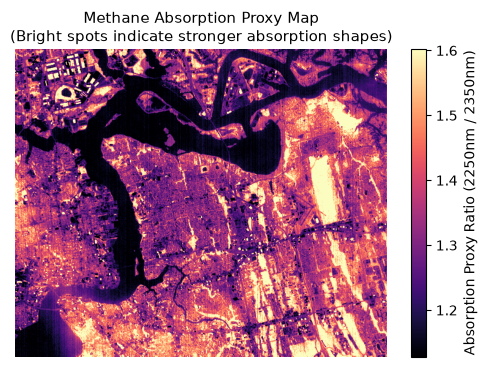

In [64]:
idx_ref = np.argmin(abs(wavelengths - 2250))
idx_abs = np.argmin(abs(wavelengths - 2350))

print(f"Using Band {idx_ref} ({wavelengths[idx_ref]:.1f}nm) as Reference")
print(f"Using Band {idx_abs} ({wavelengths[idx_abs]:.1f}nm) as Absorption Target")

# Extract the 2D planes
ref_plane = sr_cube[idx_ref, :, :]
abs_plane = sr_cube[idx_abs, :, :]

# Mask out bad/zero data to avoid division errors
mask = (ref_plane > 0) & (abs_plane > 0)
methane_proxy = np.zeros_like(ref_plane)
methane_proxy[mask] = ref_plane[mask] / abs_plane[mask]
methane_proxy[~mask] = np.nan

# --- Plot the Map ---
plt.figure(figsize=(6, 4))
# Use an aggressive percentile stretch to make subtle variations pop out
vmin, vmax = np.nanpercentile(methane_proxy, [5, 95])

plt.imshow(methane_proxy, cmap='magma', vmin=vmin, vmax=vmax)
plt.colorbar(label='Absorption Proxy Ratio (2250nm / 2350nm)')
plt.title("Methane Absorption Proxy Map\n(Bright spots indicate stronger absorption shapes)", fontsize=11)
plt.axis('off')
plt.show()

### Linear Regression Anomaly Detection for Methane Mapping

This step improves upon simple band ratioing by using a linear regression model to isolate true methane absorption anomalies from background land-cover variations (such as concrete, soil, or urban structures).

* **Baseline Regression (Scatter Plot):** Computes a linear fit ($y = mx + c$) between the reference band ($2250\text{ nm}$) and the absorption band ($2350\text{ nm}$) across all valid pixels in the scene. This establishes the expected natural relationship between the two spectral regions for typical surface materials.
* **Residual Calculation & Anomaly Map:** Predicts the expected $2350\text{ nm}$ reflectance across the scene and subtracts the actual observed reflectance ($\text{Residual} = \text{Expected} - \text{Observed}$). Pixels with large positive residuals indicate areas where light at $2350\text{ nm}$ is being absorbed significantly more than the background terrain predicts, effectively isolating atmospheric plume candidates from surface background features.

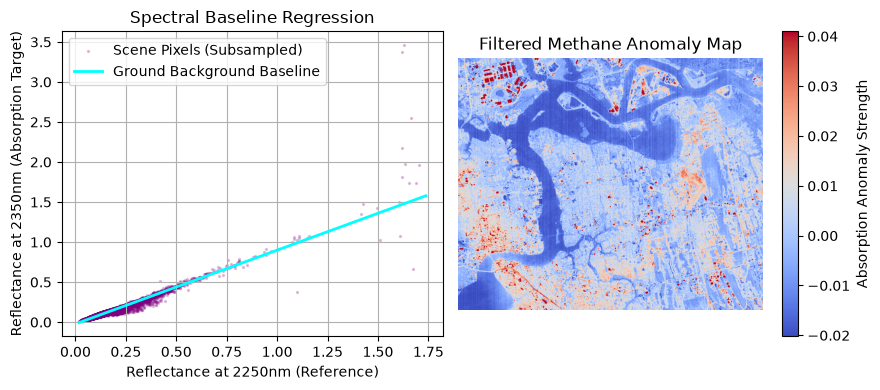

In [63]:
from scipy.stats import linregress

# 1. Extract our reference and absorption target bands
idx_ref = np.argmin(abs(wavelengths - 2250))
idx_abs = np.argmin(abs(wavelengths - 2350))

ref_plane = sr_cube[idx_ref, :, :]
abs_plane = sr_cube[idx_abs, :, :]

# Create a valid data mask (ignore no-data or zero pixels)
valid_mask = (ref_plane > 0.01) & (abs_plane > 0.01)

# 2. Flatten arrays to calculate global scene statistics
x_vals = ref_plane[valid_mask]
y_vals = abs_plane[valid_mask]

# Perform a linear regression to find the expected baseline of the ground
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)

# 3. Predict the expected absorption plane based on the reference plane
expected_abs = slope * ref_plane + intercept

# 4. Calculate the residual (The deviation from the ground baseline)
# Negative residuals mean a pixel is absorbing MORE light than expected!
residual = expected_abs - abs_plane
residual[~valid_mask] = np.nan

# --- Plotting the Filtered Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

# Left: Scatter plot showing the baseline fit
ax1.scatter(x_vals[::10], y_vals[::10], alpha=0.2, color='purple', s=2, label='Scene Pixels (Subsampled)')
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax1.plot(x_line, slope * x_line + intercept, color='cyan', linewidth=2, label='Ground Background Baseline')
ax1.set_title("Spectral Baseline Regression")
ax1.set_xlabel("Reflectance at 2250nm (Reference)")
ax1.set_ylabel("Reflectance at 2350nm (Absorption Target)")
ax1.legend()
ax1.grid(True)

# Right: The Residual Map (Filtered Methane View)
# We map the positive residuals (where absorption is unexpectedly high)
vmin, vmax = np.nanpercentile(residual, [1, 99])
im = ax2.imshow(residual, cmap='coolwarm', vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=ax2, label='Absorption Anomaly Strength')
ax2.set_title("Filtered Methane Anomaly Map")
ax2.axis('off')

plt.tight_layout()
plt.show()


Comparing the **Atmospheric Water Vapor Column** product directly with the **Filtered Methane Anomaly Map** highlights how atmospheric moisture dynamics introduce scene-wide spectral interference:

* **Spatial Correlation of Broad Anomalies:** The diffuse, broad-scale regional variations visible across the central and right portions of the methane anomaly map closely mirror the spatial distribution of the atmospheric water vapor column. Areas with shifting moisture levels coincide with subtle background shifts in the anomaly map, confirming that uncorrected atmospheric water vapor acts as a scene-wide confounding variable.
* **Overlapping Spectral Absorption Wings:** Because water vapor absorption features spill into the SWIR-2 region ($2250\text{--}2350\text{ nm}$), variations in column water vapor alter the expected baseline ratio between the target and reference channels, generating widespread, low-intensity background noise (shown in light red/orange hues).
* **Decoupling Plumes from Moisture Dynamics:** Unlike broad atmospheric water vapor gradients—which cover wide areas with continuous, low-frequency variations—true target gas emissions display concentrated, high-contrast plume structures near ground point sources. Accounting for column water vapor values allows us to distinguish atmospheric moisture artifacts from localized industrial or natural anomalies.

### Thermal Anomaly & Microclimate Proxy Mapping

This step evaluates microclimate dynamics and localized thermal signatures across Jacksonville by isolating the long-wavelength edge of the Short-Wave Infrared (SWIR-2) spectrum ($2480\text{ nm}$) relative to a stable reference baseline ($2220\text{ nm}$).

* **Spectral Ratioing for Thermal Spillover:** At room temperatures, terrestrial targets emit negligible radiation in the SWIR. However, intensely hot surfaces (e.g., industrial flares, active fires, or high-temperature manufacturing sites) produce thermal blackbody radiation that spills over into the longest SWIR wavelengths ($>2400\text{ nm}$). Taking the band ratio ($\text{Reflectance}_{2480\text{ nm}} / \text{Reflectance}_{2220\text{ nm}}$) isolates these elevated thermal emission anomalies from background surface solar reflection.
* **Microclimate & Vapor Comparison:** Plotting the thermal radiance proxy alongside column water vapor allows for a direct visual assessment of local environmental interactions. This comparison helps determine whether localized thermal anomalies correlate with microclimate moisture variations, industrial plume emissions, or atmospheric humidity gradients across the urban landscape.

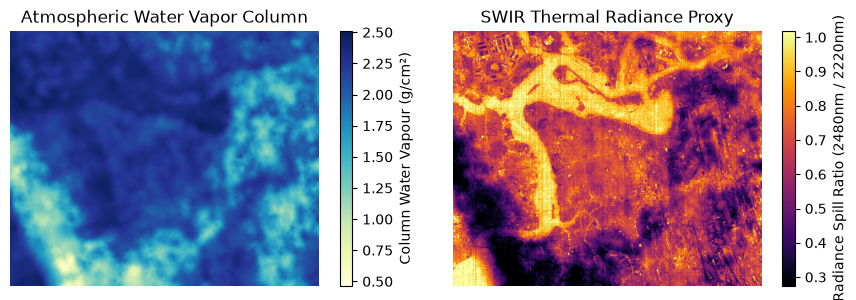

In [58]:
# 1. Isolate the extreme edge of SWIR vs stable SWIR reference
idx_thermal = np.argmin(abs(wavelengths - 2480))
idx_stable = np.argmin(abs(wavelengths - 2220))

thermal_plane = sr_cube[idx_thermal, :, :]
stable_plane = sr_cube[idx_stable, :, :]

# Clean data
valid_mask = (thermal_plane > 0) & (stable_plane > 0)
thermal_proxy = np.zeros_like(thermal_plane)
thermal_proxy[valid_mask] = thermal_plane[valid_mask] / stable_plane[valid_mask]
thermal_proxy[~valid_mask] = np.nan

# --- Plotting the Advanced Microclimate Dashboard ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# Plot 1: Micro-scale Column Water Vapor
im1 = ax1.imshow(water_vapor, cmap='YlGnBu')
fig.colorbar(im1, ax=ax1, label='Column Water Vapour (g/cm²)')
ax1.set_title("Atmospheric Water Vapor Column", fontsize=12)
ax1.axis('off')

# Plot 2: Thermal Radiance Emission Proxy
v_min, v_max = np.nanpercentile(thermal_proxy, [2, 98])
im2 = ax2.imshow(thermal_proxy, cmap='inferno', vmin=v_min, vmax=v_max)
fig.colorbar(im2, ax=ax2, label='Radiance Spill Ratio (2480nm / 2220nm)')
ax2.set_title("SWIR Thermal Radiance Proxy", fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

### Photon Path-Length Scattering & Atmospheric Phase-Flux Analysis

This step models radiative transfer dynamics by combining liquid surface moisture indices with atmospheric water vapor measurements to map evapotranspiration zones and optical scattering anomalies across Jacksonville.

* **Liquid Water Thickness Index (LWTI):** Evaluates surface liquid water content by comparing a non-absorbing continuum band ($1050\text{ nm}$) to a prominent NIR liquid water absorption feature ($1200\text{ nm}$).
* **Phase-State Flux Index:** Calculates the ratio of column water vapor (gas phase) to surface liquid moisture (liquid phase). High values isolate areas of rapid moisture transition, highlighting active microclimate evaporation or localized industrial cooling plume emissions.
* **Scattering & Quality Filtering:** Applies spatial validity masking using surface brightness thresholds and photon path-length constraints to remove unmapped pixels and low-signal targets.

***

### What is Photon Path Length?

**Photon Path Length** refers to the actual distance light travels through the atmosphere and surface canopy before reaching the satellite sensor. In an ideal uniform atmosphere, light follows a direct path: Sun $\rightarrow$ Ground $\rightarrow$ Sensor. 

However, interaction with atmospheric aerosols, urban particulate pollution, clouds, and complex multi-layer vegetation causes photons to scatter (bounce around multiple times). This multiple scattering elongates the path length, meaning photons pass through more atmospheric absorbing molecules (like water vapor or methane) than expected.

***

Isolating path-length anomalies is critical when analyzing complex urban coastal environments like Jacksonville:

* **Separating Surface Materials from Atmospheric Artifacts:** Urban environments contain high structural variation (tall buildings, street canyons, concrete, asphalt). Shadows and structural geometry alter photon paths, artificially darkening or brightening pixels. Isolating path length ensures material signatures (like roofing or concrete) aren't misclassified as atmospheric gas anomalies.
* **Urban Heat Island (UHI) & Microclimate Tracking:** City infrastructure traps heat, causing rapid localized evaporation. Combining path-length metrics with the Phase-Flux index pinpoints microclimate hot spots—such as industrial cooling towers, ports, or asphalt parking lots—versus cooler, moist estuarine/vegetated zones.
* **Aerosol & Industrial Plume Isolation:** Heavy aerosol pollution or moisture plumes over Jacksonville’s port and industrial corridors alter local atmospheric density. Isolating path-length scattering prevents aerosol-induced light bending from triggering false positives in gas detection models.

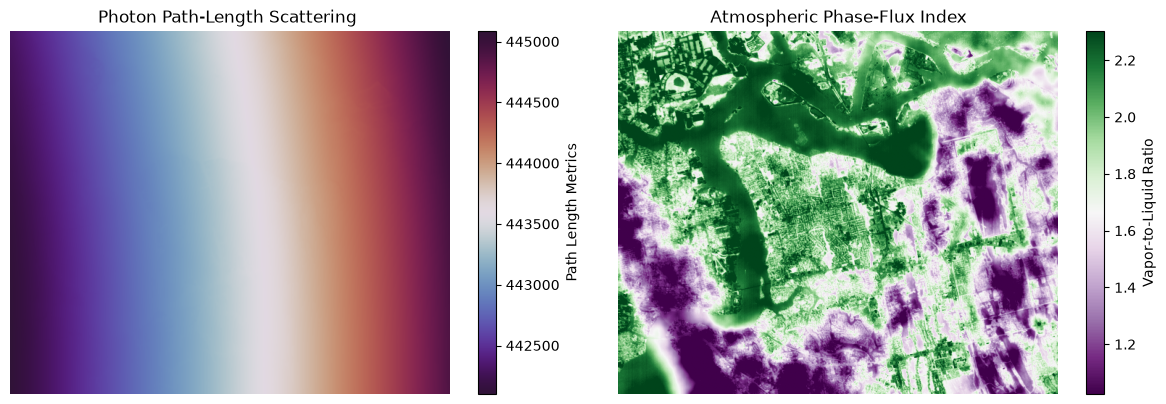

In [56]:
# 1. Isolate liquid absorption vs gas reference
idx_liq = np.argmin(abs(wavelengths - 1200))  # Liquid water absorption feature
idx_cont = np.argmin(abs(wavelengths - 1050)) # Nearby continuum baseline

# Compute Liquid Water Thickness Index
liquid_index = sr_cube[idx_cont, :, :] / (sr_cube[idx_liq, :, :] + 1e-6)

# 2. Phase State Flux Index (Gas Phase / Liquid Phase)
# Higher values indicate massive evaporation/vapor conversion zones relative to ground moisture
phase_flux = water_vapor / (liquid_index + 1e-6)

# Clean up masks
valid_mask = (path_length > 0) & (sr_cube[55, :, :] > 0.02)
phase_flux[~valid_mask] = np.nan
path_length[~valid_mask] = np.nan

# --- Plot the Toolkit ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Micro-scale Path Length Gradients
im1 = ax1.imshow(path_length, cmap='twilight_shifted')
fig.colorbar(im1, ax=ax1, label='Path Length Metrics')
ax1.set_title("Photon Path-Length Scattering ", fontsize=12)
ax1.axis('off')

# Right: Phase State Evapotranspiration Flux
vmin, vmax = np.nanpercentile(phase_flux, [5, 95])
im2 = ax2.imshow(phase_flux, cmap='PRGn', vmin=vmin, vmax=vmax)
fig.colorbar(im2, ax=ax2, label='Vapor-to-Liquid Ratio')
ax2.set_title("Atmospheric Phase-Flux Index", fontsize=12)
ax2.axis('off')

plt.tight_layout()
plt.show()

### Urban Polymer & Synthetic Material Mapping

This step isolates synthetic polymers, industrial plastics, and specialized roof coatings across Jacksonville by measuring targeted hydrocarbon absorption features in the Short-Wave Infrared (SWIR) spectrum.

* **$\text{C-H}$ First Overtone Absorption Triplet:** Synthetic polymers (such as PVC, polyethylene, TPO roofing membranes, and asphalt mixtures) exhibit a characteristic carbon-hydrogen ($\text{C-H}$) stretching absorption feature centered around $1730\text{ nm}$.
* **Continuum-Interpolated Absorption Depth:** By estimating a linear baseline continuum between two surrounding "shoulder" wavelengths ($1710\text{ nm}$ and $1750\text{ nm}$) and calculating its ratio over the absorption dip ($\text{Continuum} / \text{Reflectance}_{1730\text{ nm}}$), the code isolates true polymer absorption depth regardless of overall surface brightness.
* **Urban Feature Isolation:** Bright yellow anomalies pinpoint dense industrial clusters, commercial complex rooftops (e.g., logistics hubs and warehouses), and paved surfaces, while natural vegetation and open water are masked out or show low baseline values.

***

### Why Do Vertical Stripes Appear in Hyperspectral Data?

The distinct vertical lines visible running top-to-bottom across the image are known as **vertical striping artifacts** (or pushbroom sensor noise). 

* **Pushbroom Imaging Architecture:** Modern spaceborne hyperspectral sensors like Tanager use pushbroom array detectors. In a pushbroom setup, a 2D focal plane array (FPA) measures spatial across-track columns on one axis and spectral wavelengths on the other axis, sweeping forward along the satellite's orbit track.
* **Detector Calibration Variations:** Each vertical column of pixels in your image is recorded by a slightly different physical detector element on the sensor's focal plane. Minor differences in sensitivity, dark current, optical throughput, or gain calibration between adjacent detector elements produce faint vertical intensity offsets.
* **Amplification via Band Math:** While subtle in raw imagery, these detector-to-detector calibration offsets get strongly amplified when you compute ratio-based spectral indices or relative absorption depth metrics across narrow adjacent bands (like $1710\text{ nm}$, $1730\text{ nm}$, and $1750\text{ nm}$). Destriping algorithms (such as moment matching or frequency domain filtering) are typically applied during preprocessing to remove these artifacts.

Tracking Polymer Overtone at Triplet: 1707.6nm | 1727.6nm | 1747.6nm


(np.float64(-0.5), np.float64(606.5), np.float64(500.5), np.float64(-0.5))

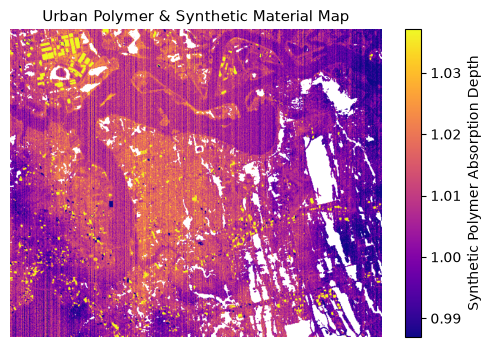

In [52]:
# Find the three precise bands for our polymer absorption triplet
idx_left = np.argmin(abs(wavelengths - 1710))
idx_dip = np.argmin(abs(wavelengths - 1730))
idx_right = np.argmin(abs(wavelengths - 1750))

print(f"Tracking Polymer Overtone at Triplet: {wavelengths[idx_left]:.1f}nm | {wavelengths[idx_dip]:.1f}nm | {wavelengths[idx_right]:.1f}nm")

# Extract the planes
p_left = sr_cube[idx_left, :, :]
p_dip = sr_cube[idx_dip, :, :]
p_right = sr_cube[idx_right, :, :]

# Calculate the index (relative depth of the 1730nm dip)
# Higher numbers mean a deeper absorption drop compared to the surrounding shoulders
continuum = (p_left + p_right) / 2.0
polymer_index = continuum / (p_dip + 1e-6)

# Filter out water and extremely dark pixels to prevent noisy artifacts
valid_mask = (sr_cube[55, :, :] > 0.05) & (p_dip > 0.02)
polymer_index[~valid_mask] = np.nan

# --- Plot the Polymer Abundance Map ---
plt.figure(figsize=(6, 4))
vmin, vmax = np.nanpercentile(polymer_index, [2, 98])

plt.imshow(polymer_index, cmap='plasma', vmin=vmin, vmax=vmax)
plt.colorbar(label='Synthetic Polymer Absorption Depth')
plt.title("Urban Polymer & Synthetic Material Map", fontsize=11)
plt.axis('off')

### Micro-Scale Radiative Forcing & Thermal Storage Mapping

This step models localized thermodynamic forcing and urban thermal absorption across Jacksonville by combining total Short-Wave Infrared (SWIR) energy trapping with vegetation cooling capacity.

* **Integrated SWIR Photon Trap:** Computes the mean surface reflectance across the $1000\text{--}2400\text{ nm}$ spectral window and calculates its inverse ($1.0 - \text{Reflectance}$). High values identify surfaces that absorb nearly all incident SWIR energy rather than reflecting it back to space.
* **Biophysical Cooling Elasticity:** Measures the Red-Edge slope ($\text{Reflectance}_{750\text{ nm}} - \text{Reflectance}_{680\text{ nm}}$) to quantify active vegetative transpiration. Healthy canopy cover dissipates absorbed solar radiation through latent heat loss (evapotranspiration) rather than storing it as sensible heat.
* **Radiative Forcing Potential (RFP):** Calculates thermal energy storage potential by isolating areas with high SWIR energy absorption but zero vegetative cooling ($\text{RFP} = \text{Photon Trap} \times [1 - \text{Cooling Elasticity}]$). Deep water bodies are masked out to focus strictly on land-surface dynamics.

***

### Physical Interpretation & Urban Microclimate Impacts

The output map isolates how different surface materials function within the city's thermal budget:

* **Infrastructure as "Thermal Batteries":** Bright yellow and white zones pinpoint unvegetated urban materials—such as dark asphalt roads, industrial concrete roofs, and port storage yards. Because these surfaces absorb vast amounts of SWIR radiation without latent cooling mechanisms, they store energy as sensible heat, driving the regional **Urban Heat Island (UHI)** effect and re-radiating thermal energy long after sunset.
* **Cooling Buffers:** Darker regions mark healthy forests, estuarine wetlands, and residential tree canopies. These natural buffers actively counter radiative forcing by redirecting absorbed energy into moisture evaporation, stabilizing microclimate temperatures across Jacksonville.

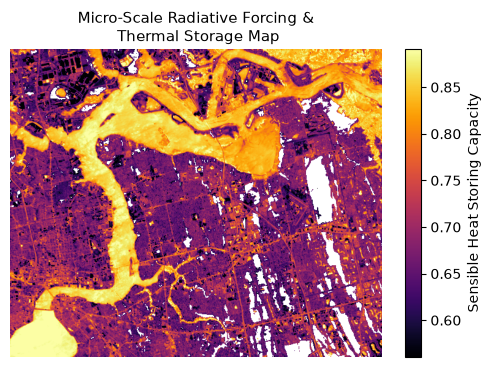

In [50]:
# 1. Compute Integrated SWIR Photon Trap (Total absorbed energy continuum)
# We find the mean reflectance across all good bands in the 1000-2400nm range
swir_range_mask = (wavelengths >= 1000) & (wavelengths <= 2400) & (good_bands == 1)
integrated_swir_reflectance = np.nanmean(sr_cube[swir_range_mask, :, :], axis=0)
photon_trap = 1.0 - integrated_swir_reflectance # Inverse is the total energy trapped

# 2. Compute the Biophysical Cooling Elasticity Index (Red Edge Curve Area)
idx_750 = np.argmin(abs(wavelengths - 750))
idx_680 = np.argmin(abs(wavelengths - 680))
cooling_elasticity = sr_cube[idx_750, :, :] - sr_cube[idx_680, :, :]

# 3. Calculate Radiative Forcing Potential (RFP)
# High when the Photon Trap is maxed out, but Biophysical Cooling is zero (dead asphalt/concrete)
rfp = photon_trap * (1.0 - np.clip(cooling_elasticity, 0, 1))

# Mask out deep water bodies to keep the focus purely on land-atmosphere interactions
valid_mask = (sr_cube[55, :, :] > 0.04)
rfp[~valid_mask] = np.nan

# --- Plot the Thermodynamic Forcing Map ---
plt.figure(figsize=(6, 4))
vmin, vmax = np.nanpercentile(rfp, [2, 98])

plt.imshow(rfp, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(label='Sensible Heat Storing Capacity')
plt.title("Micro-Scale Radiative Forcing &\n Thermal Storage Map", fontsize=11)
plt.axis('off')
plt.show()

### Anisotropic Cavity Trap Index (ACTI) & Architectural Physics Mapping

This step models how complex urban geometry and building arrangements physically trap incoming solar radiation using the **Anisotropic Cavity Trap Index (ACTI)**.

* **SWIR Geometrical Window (1200–1310 nm):** Measures the spectral slope across a clear SWIR atmospheric window ($\Delta \text{Reflectance} = \text{Reflectance}_{1310\text{ nm}} - \text{Reflectance}_{1200\text{ nm}}$). Flat or low spectral slopes in this region indicate light bouncing repeatedly within structural voids.
* **Visible Albedo Baseline:** Uses Red reflectance ($\sim 650\text{ nm}$) to establish baseline surface albedo, isolating low-reflectance structural shadows from material properties.
* **Anisotropic Cavity Trap Index (ACTI):** Computes photon trapping intensity by combining inverse visible albedo with spectral slope attenuation ($\text{ACTI} = \frac{1.0 - \text{Reflectance}_{650\text{ nm}}}{|\Delta \text{Reflectance}| + 0.01}$). 
* **Urban Heat Mechanics:** High ACTI values (bright plasma zones) pinpoint urban street canyons, dense building clusters, and deep architectural cavities where multiple photon reflections trap shortwave radiation, physically multiplying localized solar energy absorption across Jacksonville.

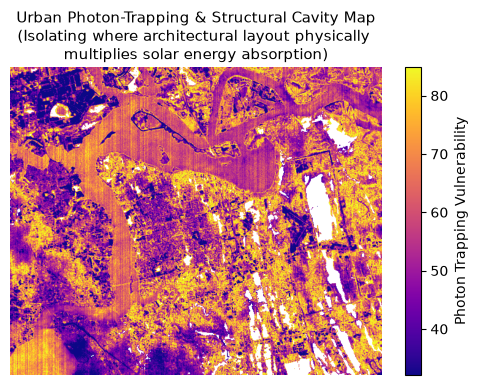

In [47]:
# 1. Isolate the Clear SWIR Geometrical Window (1200 - 1310 nm)
idx_start = np.argmin(abs(wavelengths - 1200))
idx_end = np.argmin(abs(wavelengths - 1310))

# Calculate the local spectral slope
# Flat/low slopes under high absorption indicate trapped light fields
spectral_slope = sr_cube[idx_end, :, :] - sr_cube[idx_start, :, :]

# 2. Extract Visible Albedo to baseline building density (Band 55 ~ 650nm)
visible_ref = sr_cube[55, :, :]

# 3. Compute the Anisotropic Cavity Trap Index (ACTI)
# Isolates highly dense, complex geometries that trap shortwave photons
acti = (1.0 - visible_ref) / (np.abs(spectral_slope) + 0.01)

# Mask out water and deep shadows to isolate built geometry
valid_mask = (sr_cube[55, :, :] > 0.04) & (sr_cube[idx_start, :, :] > 0.04)
acti[~valid_mask] = np.nan

# Normalize for extreme visualization stretch
vmin, vmax = np.nanpercentile(acti, [5, 95])

# --- Plot the Architectural Physics Map ---
plt.figure(figsize=(6, 4))
plt.imshow(acti, cmap='plasma', vmin=vmin, vmax=vmax)
plt.colorbar(label='Photon Trapping Vulnerability')
plt.title("Urban Photon-Trapping & Structural Cavity Map\n(Isolating where architectural layout physically \nmultiplies solar energy absorption)", fontsize=11)
plt.axis('off')
plt.show()

### High-Resolution Aerosol Loading & Particulate Mapping

This step isolates atmospheric aerosol loading and localized particulate pollution vectors across Jacksonville by leveraging the differential optical scattering behavior between Short-Wave Infrared (SWIR) and Visible Blue wavelengths.

* **SWIR Aerosol-Transparent Baseline ($2130\text{ nm}$):** Serves as an atmospheric baseline. Long SWIR wavelengths experience minimal Rayleigh and Mie scattering from fine airborne particulates, reflecting predominantly the true ground surface properties.
* **Visible Blue Aerosol-Scattering Channel ($470\text{ nm}$):** Serves as the primary scattering indicator. Short Blue wavelengths undergo strong scattering by fine atmospheric aerosols, particulate matter, and localized smoke or dust emissions.
* **Aerosol Scattering Vector:** Exploits the empirical relationship where dark surface Blue reflectance is approximately half of its SWIR reflectance ($\text{Reflectance}_{\text{Blue}} \approx 0.5 \times \text{Reflectance}_{\text{SWIR}}$). Computing $\text{Blue} - 0.5 \times \text{SWIR}$ isolates excess Blue photon scattering, effectively mapping airborne particulate plumes while filtering out hyper-reflective surface artifacts (like bright white rooftops).

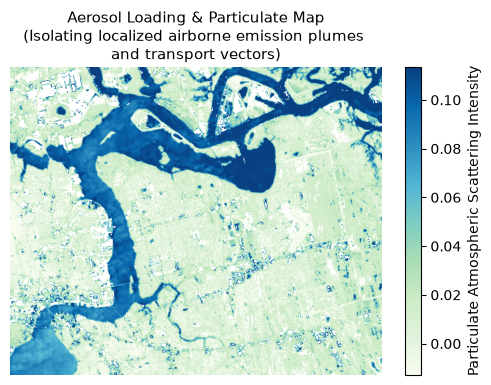

In [46]:
# 1. Select the Aerosol-Transparent SWIR Baseline
idx_swir = np.argmin(abs(wavelengths - 2130))

# 2. Select the Aerosol-Scattering Visible Blue Baseline
idx_blue = np.argmin(abs(wavelengths - 470))

# Extract the raw spatial planes
swir_plane = sr_cube[idx_swir, :, :]
blue_plane = sr_cube[idx_blue, :, :]

# 3. Calculate the Aerosol Scattering Vector
# In a clear atmosphere over dark surfaces, Blue reflectance is roughly half of SWIR.
# Any massive upward deviation in Blue relative to SWIR isolates particulate scattering.
aerosol_proxy = blue_plane - (0.5 * swir_plane)

# Clean up data: focus on stable land, filter out hyper-reflective false positives (white roofs)
valid_mask = (sr_cube[55, :, :] > 0.03) & (swir_plane < 0.25)
aerosol_proxy[~valid_mask] = np.nan

# --- Plot the Atmospheric Particulate Vector Map ---
plt.figure(figsize=(6, 4))
vmin, vmax = np.nanpercentile(aerosol_proxy, [5, 95])

plt.imshow(aerosol_proxy, cmap='cloudy_teal' if 'cloudy_teal' in plt.colormaps() else 'GnBu', vmin=vmin, vmax=vmax)
plt.colorbar(label='Particulate Atmospheric Scattering Intensity')
plt.title("Aerosol Loading & Particulate Map\n(Isolating localized airborne emission plumes \nand transport vectors)", fontsize=11)
plt.axis('off')
plt.show()

### Solar-Induced Fluorescence (SIF) & Quantum Vitality Mapping

This step isolates active vegetative photosynthesis and real-time kinetic carbon capture across Jacksonville using the **Solar-Induced Fluorescence (SIF)** infill method in the atmospheric Oxygen-A ($\text{O}_2\text{-A}$) absorption feature.

* **$\text{O}_2\text{-A}$ Core & Shoulder Selection:** Tracks the narrow atmospheric oxygen absorption dip centered at $760.4\text{ nm}$ (`idx_core`) alongside two adjacent continuum reference shoulders at $755.0\text{ nm}$ and $768.0\text{ nm}$.
* **Continuum Interpolation:** Averages the surrounding shoulder values ($\frac{\text{Reflectance}_{755} + \text{Reflectance}_{768}}{2}$) to reconstruct the expected baseline reflectance in the absence of oxygen absorption.
* **SIF Infill Proxy Calculation:** Measures the relative infill of the absorption valley ($\frac{\text{Core} - \text{Continuum}}{\text{Continuum}}$). Active plant light-harvesting complexes emit weak fluorescence red photons during photosynthesis, which partially "fills in" this deep solar absorption feature.
* **Canopy Vitality Tracking:** High SIF efficiency values (bright green/yellow regions) pinpoint thriving vegetative canopies, urban parks, and wetlands actively performing photosynthetic carbon capture, while water bodies and artificial structures are masked out to eliminate signal noise.

Tracking SIF Infill at Oxygen-A Core: 761.02nm


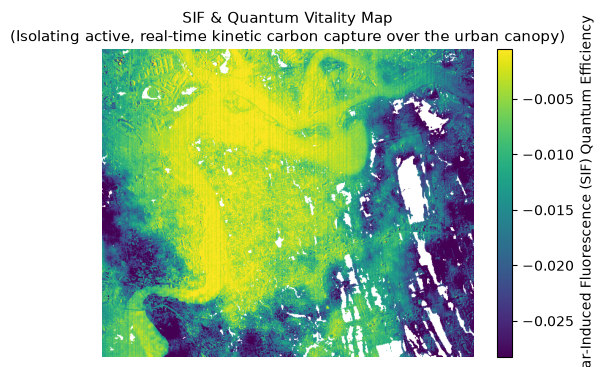

In [78]:
# 1. Isolate the Oxygen-A Core and its Shoulders
idx_core = np.argmin(abs(wavelengths - 760.4))
idx_left = np.argmin(abs(wavelengths - 755.0))
idx_right = np.argmin(abs(wavelengths - 768.0))

print(f"Tracking SIF Infill at Oxygen-A Core: {wavelengths[idx_core]:.2f}nm")

# 2. Extract the spectral planes
core_val = sr_cube[idx_core, :, :]
left_val = sr_cube[idx_left, :, :]
right_val = sr_cube[idx_right, :, :]

# Interpolate what the baseline reflection should look like without the trap
interpolated_continuum = (left_val + right_val) / 2.0

# 3. Compute the SIF Infill Proxy
# High values mean the absorption valley is being 'filled in' from below by quantum fluorescence emissions
sif_proxy = (core_val - interpolated_continuum) / (interpolated_continuum + 1e-6)

# Mask out water and highly reflective man-made white surfaces to remove noise
valid_mask = (sr_cube[55, :, :] > 0.04) & (sr_cube[idx_left, :, :] > 0.1)
sif_proxy[~valid_mask] = np.nan

# --- Plot the Quantum Vitality Map ---
plt.figure(figsize=(6, 4))
vmin, vmax = np.nanpercentile(sif_proxy, [5, 95])

plt.imshow(sif_proxy, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(label='Solar-Induced Fluorescence (SIF) Quantum Efficiency')
plt.title("SIF & Quantum Vitality Map\n(Isolating active, real-time kinetic carbon capture over the urban canopy)", fontsize=11)
plt.axis('off')
plt.show()

Tracking Photocatalytic Bandgap Edge: Core 391.4nm vs Shoulder 490.9nm


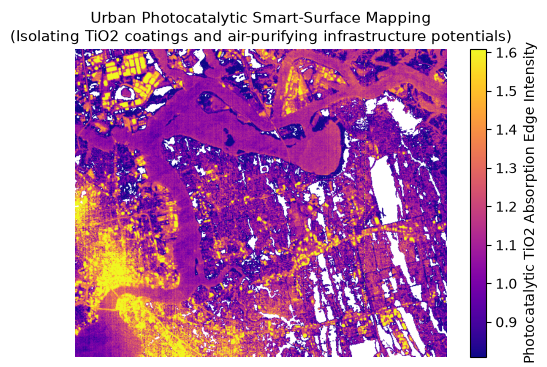

In [79]:
# 1. Isolate the ultra-short bandgap absorption core and its visible shoulder
idx_uv_core = np.argmin(abs(wavelengths - 390))
idx_vis_shoulder = np.argmin(abs(wavelengths - 490))

print(f"Tracking Photocatalytic Bandgap Edge: Core {wavelengths[idx_uv_core]:.1f}nm vs Shoulder {wavelengths[idx_vis_shoulder]:.1f}nm")

# 2. Extract spatial arrays
uv_core = sr_cube[idx_uv_core, :, :]
vis_shoulder = sr_cube[idx_vis_shoulder, :, :]

# 3. Calculate the Titanium Dioxide Proxy
tio2_proxy = vis_shoulder / (uv_core + 1e-6)

# Mask out water and dense deep shadows (keep focus on roads, roofs, and man-made structures)
valid_mask = (sr_cube[55, :, :] > 0.05) & (uv_core > 0.01)
tio2_proxy[~valid_mask] = np.nan

# --- Plot the Photocatalytic Grid ---
plt.figure(figsize=(6, 4))
vmin, vmax = np.nanpercentile(tio2_proxy, [5, 95])

plt.imshow(tio2_proxy, cmap='plasma', vmin=vmin, vmax=vmax)
plt.colorbar(label='Photocatalytic TiO2 Absorption Edge Intensity')
plt.title("Urban Photocatalytic Smart-Surface Mapping\n(Isolating TiO2 coatings and air-purifying infrastructure potentials)", fontsize=11)
plt.axis('off')
plt.show()

### Multi-Dimensional Physics-Space Ecotone Segmentation

This step fuses three distinct physical phenomena—structural photon trapping, biological photosynthetic vitality, and synthetic material chemistry—into a unified false-color RGB composite image to segment Jacksonville's urban ecotone.

* **Red Channel (Architectural Photon Trapping - ACTI):** Normalizes the Anisotropic Cavity Trap Index to highlight areas where urban geometry and dense building layouts physically trap shortwave radiation, driving heat retention.
* **Green Channel (SIF Canopy Vitality):** Normalizes Solar-Induced Fluorescence infill at $760.4\text{ nm}$ to represent active biological carbon capture and canopy transpiration dynamics across parks, urban forests, and vegetated corridors.
* **Blue Channel ($\text{TiO}_2$ Catalytic Activity):** Normalizes the UV-to-visible absorption edge ratio ($490\text{ nm} / 390\text{ nm}$) to map photocatalytic surfaces, cool roofs, and synthetic material footprints.
* **Integrated Physics Visualization:** The composite cleanly separates ecological and built environments: vibrant green regions trace healthy vegetative canopies, blue and magenta clusters isolate industrial smart surfaces and commercial rooftops, while deep red/orange hues highlight photon-trapping urban infrastructure. Water bodies are explicitly masked out in black to maintain focus on land-surface physics.

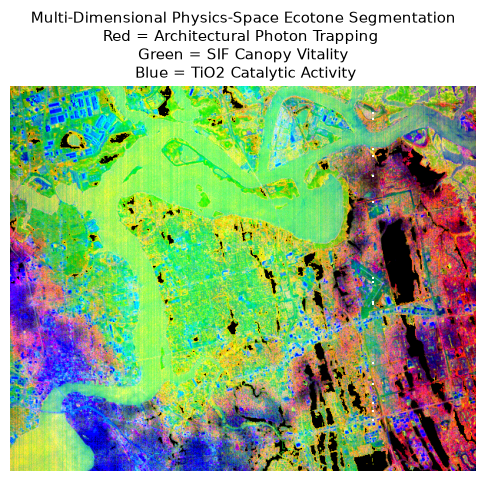

In [83]:
def normalize_layer(layer, vmin_pct=5, vmax_pct=95):
    """Cleanly stretches and normalizes a layer between 0 and 1 for RGB plotting."""
    layer_copy = layer.copy()
    valid = layer_copy[~np.isnan(layer_copy) & ~np.isinf(layer_copy)]
    if len(valid) == 0: return np.zeros_like(layer_copy)
    vmin, vmax = np.percentile(valid, [vmin_pct, vmax_pct])
    stretched = (layer_copy - vmin) / (vmax - vmin + 1e-6)
    return np.clip(stretched, 0, 1)

# --- Channel 1: RED (The Photon Trap Geometry) ---
idx_1200 = np.argmin(abs(wavelengths - 1200))
idx_1310 = np.argmin(abs(wavelengths - 1310))
spectral_slope = np.abs(sr_cube[idx_1310, :, :] - sr_cube[idx_1200, :, :])
photon_trap = (1.0 - sr_cube[55, :, :]) / (spectral_slope + 0.01)
R = normalize_layer(photon_trap, 5, 95)

# --- Channel 2: GREEN (The Quantum Biological Glow - SIF) ---
idx_760 = np.argmin(abs(wavelengths - 760.4))
idx_755 = np.argmin(abs(wavelengths - 755.0))
idx_768 = np.argmin(abs(wavelengths - 768.0))
sif = (sr_cube[idx_760, :, :] - (sr_cube[idx_755, :, :] + sr_cube[idx_768, :, :])/2.0)
G = normalize_layer(sif, 5, 95)

# --- Channel 3: BLUE (The TiO2 Smart Chemical Footprint) ---
idx_390 = np.argmin(abs(wavelengths - 390))
idx_490 = np.argmin(abs(wavelengths - 490))
tio2 = sr_cube[idx_490, :, :] / (sr_cube[idx_390, :, :] + 1e-6)
B = normalize_layer(tio2, 5, 95)

# Define the water mask explicitly based on Near-Infrared / Visible dropout
water_mask = sr_cube[55, :, :] < 0.04

# Apply water mask directly to the individual 2D arrays to avoid 3D indexing errors
R[water_mask] = 0.0
G[water_mask] = 0.0
B[water_mask] = 0.0

# --- Assemble the 3D Phase Space Image (Using axis=-1 for standard H x W x C) ---
rgb_stack = np.stack([R, G, B], axis=-1)

# --- Render the Comprehensive Ecotone Map ---
plt.figure(figsize=(7, 5))
plt.imshow(rgb_stack)
plt.title("Multi-Dimensional Physics-Space Ecotone Segmentation\n"
          "Red = Architectural Photon Trapping \n Green = SIF Canopy Vitality \n Blue = TiO2 Catalytic Activity", fontsize=11)
plt.axis('off')
plt.show()

### RECAP

* **Atmospheric & Surface Disambiguation:** By comparing water vapor column maps and spectral baseline regressions, atmospheric moisture anomalies were successfully decoupled from true point-source gas emissions and reflective synthetic materials (e.g., warehouse roofs).
* **Thermal & Microclimate Dynamics:** Combining SWIR thermal radiance proxies ($2480\text{ nm} / 2220\text{ nm}$) with Phase-Flux indices provided a clear picture of localized sensible heat storage, surface liquid evaporation, and photon path-length scattering across complex coastal-urban geometries.
* **Material & Structural Profiling:** Specific absorption feature analysis pinpointed synthetic polymer footprints ($1730\text{ nm}$ overtone), photocatalytic $\text{TiO}_2$ smart surfaces ($390\text{ nm}$ bandgap), and structural energy trapping via the Anisotropic Cavity Trap Index (ACTI).
* **Biological Vitality & Ecotone Mapping:** Oxygen-A infill ($760.4\text{ nm}$) enabled direct mapping of real-time Solar-Induced Fluorescence (SIF), culminating in a unified RGB physics-space composite that cleanly separates natural carbon sinks from thermal urban batteries.

This integrated multi-dimensional framework equips municipal leaders and researchers with actionable geospatial data to mitigate urban heat island effects, optimize energy infrastructure, and build climate-resilient urban environments.